# BQ1 — รัฐใดน่าเข้าไปลงทุนที่สุด

**คำถาม (จากเอกสารออกแบบ):** รัฐใดน่าเข้าไปลงทุนที่สุด เมื่อดู
*จำนวนเตียงต่อประชากรสูงอายุพันคน*, *อัตราการเข้าพักเฉลี่ย* และ *คะแนนคุณภาพของคู่แข่ง*
— ผู้ใช้คือ CEO

**ทำไมสามตัวนี้รวมกันจึงตอบได้**

| ตัวชี้วัด | ทิศทางที่น่าลงทุน | เพราะ |
|---|---|---|
| เตียงต่อผู้สูงอายุ 1,000 คน | **ต่ำ** | อุปทานยังไม่พอกับอุปสงค์ |
| อัตราการเข้าพัก | **สูง** | เตียงที่มีอยู่เต็มแล้ว อุปสงค์เป็นของจริง ไม่ใช่แค่ทฤษฎีประชากร |
| คะแนนดาวเฉลี่ยของคู่แข่ง | **ต่ำ** | คู่แข่งอ่อน ผู้เล่นใหม่ที่บริหารดีมีที่ยืน |

ตัวเดียวโดด ๆ หลอกได้ทุกตัว — รัฐที่เตียงน้อยเพราะไม่มีคนแก่ ก็ไม่ใช่โอกาส
ต้องดูพร้อมกันทั้งสามตัว

**หมายเหตุเรื่องโครงสร้าง:** ตรรกะ query อยู่ใน `queries.py` และกราฟอยู่ใน `charts.py`
ไม่ได้อยู่ในเซลล์ notebook — เพื่อให้แอป Streamlit ที่จะส่งใช้ฟังก์ชันเดียวกันได้
ตัวเลขที่ตรวจในนี้จึงเป็นตัวเลขเดียวกับที่แอปวาด ไม่ต้องเขียนใหม่

## 1. ต่อฐานข้อมูล และดูว่ามีอะไรอยู่

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import charts
import queries as q

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

con = q.connect()
print("ตารางในคลังข้อมูล:")
for (name,) in con.execute("SHOW TABLES").fetchall():
    n = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"  {name:<24} {n:>9,} rows")

ตารางในคลังข้อมูล:
  Dim_Chain                      652 rows
  Dim_Date                    24,838 rows
  Dim_Facility                25,937 rows
  Dim_Geography                9,729 rows
  Dim_Ownership                   14 rows
  Dim_Penalty_Type                 3 rows
  Fact_Facility_Monthly       59,665 rows
  Fact_Penalty_Event          27,529 rows
  Ref_State_Population           255 rows
  etl_run_log                  1,359 rows


### งวดที่มีให้เลือก

BQ1 เป็นคำถามเชิงการลงทุน = สนใจ**สถานะปัจจุบัน** จึงใช้งวดล่าสุด
(ถ้าอยากดูย้อนหลังให้ส่ง `period_key` เข้าไป)

In [2]:
periods = q.available_periods(con)
print(periods.to_string(index=False))
print()
print("ปีของข้อมูลประชากรที่มี:", q.population_years(con))

 period_key     period  year  facilities
   20190101 2019-01-01  2019       15578
   20260401 2026-04-01  2026       14699
   20260601 2026-06-01  2026       14695
   20260701 2026-07-01  2026       14693

ปีของข้อมูลประชากรที่มี: [2020, 2021, 2022, 2023, 2024]


## 2. ตัวเลขระดับชาติ — เส้นเทียบที่ต้องมีก่อน

ถ้าไม่มีตัวเลขระดับชาติ คำว่า "16 เตียงต่อพันคน" ไม่มีความหมายกับคนอ่าน

In [3]:
baseline = q.bq1_national_baseline(con)

print(f"งวด               {baseline['period']}")
print(f"ประชากรใช้ปี       {baseline['population_year']}  ({baseline['population_note']})")
print()
print(f"  สถานพยาบาล            {baseline['facilities']:>12,}")
print(f"  เตียงรวม              {baseline['beds']:>12,}")
print(f"  ประชากร 65+           {baseline['pop_65plus']:>12,}")
print()
print(f"  เตียงต่อผู้สูงอายุ 1,000 คน   {baseline['beds_per_1k_65plus']:>8.2f}")
print(f"  อัตราการเข้าพัก              {baseline['occupancy']:>8.1%}")
print(f"  คะแนนดาวเฉลี่ย               {baseline['avg_overall_rating']:>8.2f}  / 5")

งวด               2026-07-01
ประชากรใช้ปี       2024  (nearest available year (2024 vs 2026))

  สถานพยาบาล                  14,667
  เตียงรวม                 1,566,875
  ประชากร 65+             61,179,918

  เตียงต่อผู้สูงอายุ 1,000 คน      25.61
  อัตราการเข้าพัก                 80.2%
  คะแนนดาวเฉลี่ย                   2.99  / 5


### ตรวจความสมเหตุสมผลก่อนไปต่อ

ตัวเลขข้างบนต้องผ่านสายตาก่อน ไม่ใช่เชื่อเพราะโค้ดรันผ่าน

- **เตียงต่อผู้สูงอายุพันคน ~25** → ผู้สูงอายุ 1,000 คนมีเตียงในสถานดูแล 25 เตียง
  หรือราว **2.5%** ของประชากรสูงอายุ ซึ่งใกล้เคียงกับสัดส่วนที่ทราบกันว่า
  ผู้สูงอายุอเมริกันอยู่ในสถานดูแลระยะยาว
- **อัตราการเข้าพัก ~80%** → สอดคล้องกับที่อุตสาหกรรมนี้ยังไม่ฟื้นเต็มที่หลัง COVID
- **คะแนนดาวเฉลี่ย ~3.0 จาก 5** → ต้องอยู่กลาง ๆ เพราะ CMS ออกแบบระบบดาว
  ให้กระจายรอบ 3 ถ้าได้ 4.5 หรือ 1.5 แปลว่าคำนวณผิด

## 3. ดึงข้อมูลรายรัฐ และดูสิ่งที่ฟังก์ชันตัดสินใจแทนเรา

`context` คือส่วนที่สำคัญไม่แพ้ตัวเลข — มันบอกว่าฟังก์ชันเลือกงวดใด ใช้ประชากรปีใด
และ**ตัดอะไรออกไป** ถ้าไม่มีท่อนนี้ กราฟจะดูเหมือนเป็นความจริงที่ไม่มีเงื่อนไข

In [4]:
frame, context = q.bq1_state_market(con, exclude_suspect=True, min_facilities=10)

for key, value in context.items():
    print(f"  {key:<32} {value}")

  period_key                       20260701
  period                           2026-07-01
  national_beds_per_1k             25.60645798838763
  period_year                      2026
  population_year                  2024
  population_note                  nearest available year (2024 vs 2026)
  exclude_suspect                  True
  min_facilities                   10
  states_returned                  53
  states_ranked                    51
  states_excluded_too_few          ['GU', 'PR']
  states_excluded_no_population    ['GU', 'PR']


**ที่ถูกตัดออกจากการจัดอันดับ (แต่ยังอยู่ในตาราง ติดธงไว้):**

- `GU`, `PR` — ไฟล์ประชากรระดับรัฐของ Census ไม่ครอบคลุมดินแดน จึงคิดต่อหัวไม่ได้
- รัฐที่มีสถานพยาบาลน้อยกว่า 10 แห่ง — มีสามแห่งแล้วปิดไปหนึ่ง อัตราส่วนเหวี่ยงทั้งรัฐ

ทั้งสองกลุ่ม**ไม่ได้ถูกลบ** แค่ติดธง `no_population` / `too_few` ไว้ ตามหลักของโปรเจกต์
ว่าติดธงดีกว่าลบทิ้ง

In [5]:
frame[["state_code", "state_name", "facilities", "beds", "pop_65plus",
       "beds_per_1k_65plus", "occupancy", "avg_overall_rating",
       "rated_facilities", "too_few", "no_population"]].head(12).round(3)

,state_code,state_name,facilities,beds,pop_65plus,beds_per_1k_65plus,occupancy,avg_overall_rating,rated_facilities,too_few,no_population
0,AK,Alaska,20,815.0,109206,7.463,0.909,3.450,20,False,False
1,AL,Alabama,224,26504.0,955901,27.727,0.829,3.004,223,False,False
2,AR,Arkansas,221,24167.0,562842,42.937,0.703,3.468,218,False,False
3,AZ,Arizona,139,15926.0,1488452,10.700,0.770,3.391,138,False,False
4,CA,California,1162,114765.0,6521873,17.597,0.881,3.170,1150,False,False
5,CO,Colorado,208,19728.0,975901,20.215,0.788,3.126,206,False,False
6,CT,Connecticut,191,22696.0,714203,31.778,0.863,3.000,190,False,False
7,DC,District of Columbia,17,2485.0,90959,27.320,0.817,3.412,17,False,False
8,DE,Delaware,44,4717.0,229028,20.596,0.841,3.233,43,False,False
9,FL,Florida,694,84517.0,5091262,16.600,0.888,3.259,691,False,False


## 4. ตรวจการรวมค่าด้วยมือ — ขั้นที่ห้ามข้าม

เอกสารออกแบบเตือนว่า **อัตราการเข้าพักต้องเป็น `SUM(ผู้พักอาศัย)/SUM(เตียง)`
ไม่ใช่ค่าเฉลี่ยของอัตราส่วนรายแห่ง** เพราะบ้าน 20 เตียงกับ 300 เตียงจะมีน้ำหนักเท่ากัน

เซลล์นี้คำนวณรัฐหนึ่งขึ้นมาใหม่จาก fact table ดิบ ๆ แล้วเทียบกับที่ฟังก์ชันให้
ถ้าไม่ตรง แปลว่าอย่าเชื่อกราฟข้างล่างทั้งหมด

In [6]:
STATE = "NM"

raw = con.execute('''
    SELECT f.certified_beds, f.avg_residents_per_day, f.overall_rating
    FROM Fact_Facility_Monthly f
    JOIN Dim_Geography g ON f.geography_key = g.geography_key
    WHERE f.snapshot_date_key = ?
      AND g.state_code = ?
      AND NOT f.is_suspect
''', [context["period_key"], STATE]).df()

pop = con.execute('''
    SELECT pop_65plus FROM Ref_State_Population
    WHERE state_code = ? AND year = ?
''', [STATE, context["population_year"]]).fetchone()[0]

by_hand = {
    "facilities": len(raw),
    "beds": raw["certified_beds"].sum(),
    "occupancy": raw["avg_residents_per_day"].sum() / raw["certified_beds"].sum(),
    "avg_overall_rating": raw["overall_rating"].mean(),   # skips nulls, as CMS intends
    "beds_per_1k_65plus": raw["certified_beds"].sum() / (pop / 1000),
}
from_query = frame.loc[frame["state_code"] == STATE].iloc[0]

print(f"{'measure':<22}{'by hand':>16}{'from queries.py':>18}   match")
for key, value in by_hand.items():
    other = float(from_query[key])
    ok = abs(float(value) - other) < 1e-9
    print(f"{key:<22}{float(value):>16.6f}{other:>18.6f}   {'OK' if ok else 'MISMATCH'}")

print()
wrong = (raw['avg_residents_per_day'] / raw['certified_beds']).mean()
print(f"อัตราการเข้าพักที่ถูก (SUM/SUM)      {by_hand['occupancy']:.4%}")
print(f"ถ้าเฉลี่ยอัตราส่วนรายแห่ง (ผิด)      {wrong:.4%}")
print(f"ต่างกัน                             {abs(by_hand['occupancy'] - wrong) * 100:.2f} จุด")

measure                        by hand   from queries.py   match
facilities                   68.000000         68.000000   OK
beds                       6919.000000       6919.000000   OK
occupancy                     0.834080          0.834080   OK
avg_overall_rating            2.850746          2.850746   OK
beds_per_1k_65plus           16.106392         16.106392   OK

อัตราการเข้าพักที่ถูก (SUM/SUM)      83.4080%
ถ้าเฉลี่ยอัตราส่วนรายแห่ง (ผิด)      84.2849%
ต่างกัน                             0.88 จุด


บรรทัดสองบรรทัดสุดท้ายคือเหตุผลที่คลังข้อมูลนี้**ไม่เก็บอัตราส่วนเป็น measure**
เก็บแต่ตัวตั้งกับตัวหาร แล้วให้หารตอน query

## 5. จัดอันดับ

คะแนนคือ **ค่าเฉลี่ยของสาม percentile** ที่ถ่วงน้ำหนักเท่ากัน
— น้ำหนักเท่ากันเป็น *ข้อสมมติ* ไม่ใช่ข้อค้นพบ จึงเก็บทั้งสาม percentile ไว้ในผลลัพธ์
ให้คนที่คิดว่าคุณภาพสำคัญกว่าอุปทานสองเท่าปรับน้ำหนักเองได้ทันที

In [7]:
ranked = q.bq1_opportunity_score(frame)

cols = ["rank", "state_code", "state_name", "facilities", "beds_per_1k_65plus",
        "occupancy", "avg_overall_rating", "pct_supply", "pct_demand",
        "pct_contest", "opportunity_score"]
ranked[cols].head(10).round(3)

,rank,state_code,state_name,facilities,beds_per_1k_65plus,occupancy,avg_overall_rating,pct_supply,pct_demand,pct_contest,opportunity_score
33,1.0,NM,New Mexico,68,16.106,0.834,2.851,0.882,0.627,0.843,0.784
47,2.0,VA,Virginia,288,21.085,0.878,2.958,0.667,0.882,0.686,0.745
42,3.0,SC,South Carolina,186,18.112,0.872,3.000,0.784,0.843,0.578,0.735
22,4.0,ME,Maine,78,17.652,0.873,3.078,0.804,0.863,0.471,0.712
51,4.0,WV,West Virginia,121,27.501,0.898,2.942,0.451,0.961,0.725,0.712
48,6.0,VT,Vermont,33,19.990,0.828,2.875,0.745,0.569,0.784,0.699
0,7.0,AK,Alaska,20,7.463,0.909,3.450,1.000,0.980,0.059,0.680
4,8.0,CA,California,1162,17.597,0.881,3.170,0.824,0.902,0.255,0.660
9,9.0,FL,Florida,694,16.600,0.888,3.259,0.863,0.922,0.176,0.654
26,10.0,MS,Mississippi,202,33.087,0.850,2.750,0.275,0.745,0.882,0.634


In [8]:
print("ห้าอันดับท้าย (ตลาดที่อิ่มตัวแล้ว):")
ranked[cols].dropna(subset=["opportunity_score"]).tail(5).round(3)

ห้าอันดับท้าย (ตลาดที่อิ่มตัวแล้ว):


,rank,state_code,state_name,facilities,beds_per_1k_65plus,occupancy,avg_overall_rating,pct_supply,pct_demand,pct_contest,opportunity_score
46,47.0,UT,Utah,97,19.348,0.705,3.302,0.765,0.137,0.118,0.340
7,48.0,DC,District of Columbia,17,27.320,0.817,3.412,0.471,0.451,0.078,0.333
13,49.0,IA,Iowa,388,41.148,0.803,3.088,0.059,0.392,0.451,0.301
16,50.0,IN,Indiana,507,40.273,0.752,3.137,0.078,0.294,0.333,0.235
2,51.0,AR,Arkansas,221,42.937,0.703,3.468,0.020,0.118,0.039,0.059


## 6. กราฟ C5 — เตียงต่อผู้สูงอายุพันคน รายรัฐ

เรียงจากน้อยไปมาก เพราะปลายที่**น้อย**คือปลายที่น่าสนใจสำหรับนักลงทุน
แถบสีน้ำเงินคือห้าอันดับแรกของคะแนนรวม ไม่ใช่ห้าอันดับแรกของกราฟนี้
— จงใจให้เห็นว่าเตียงน้อยอย่างเดียวไม่พอ

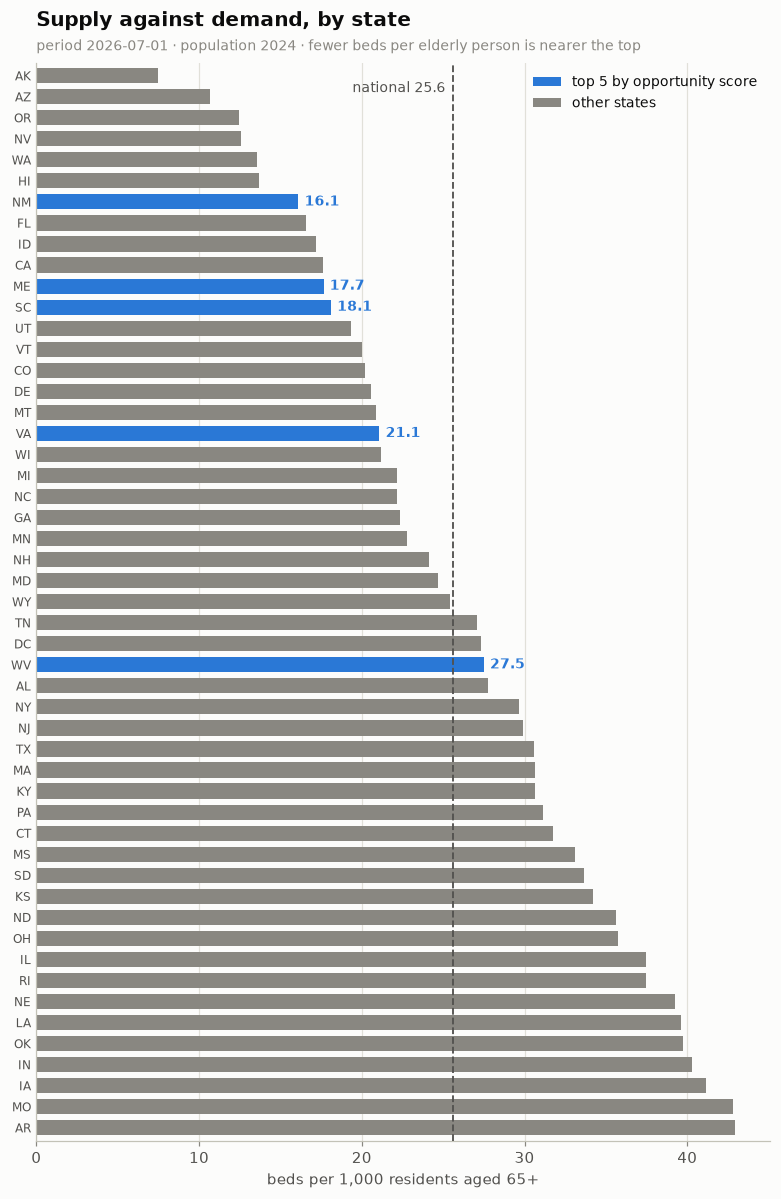

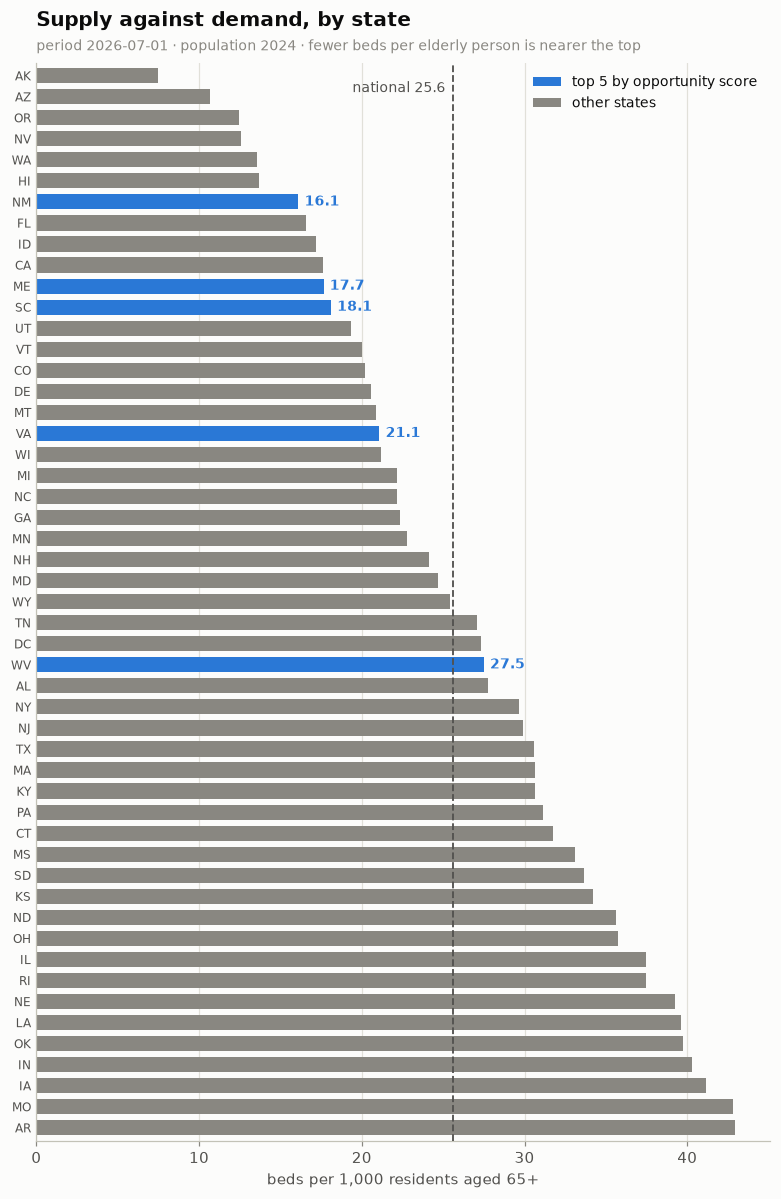

In [9]:
fig = charts.beds_per_1k_bar(ranked, context, shortlist=5)
fig.savefig("bq1_c5_beds_per_1k.png", dpi=150, bbox_inches="tight")
fig

## 7. กราฟรวมสามตัวชี้วัดในภาพเดียว

แกน x = อุปทาน · แกน y = อุปสงค์ · **สี = คุณภาพคู่แข่ง** · ขนาดจุด = จำนวนสถานพยาบาล

มุมที่น่าลงทุนคือ **ซ้ายบน** (เตียงน้อย + เต็ม) และยิ่ง**สีอ่อน**ยิ่งดี เพราะคู่แข่งคะแนนต่ำ
สีใช้ ramp สีเดียวไล่เข้ม ผ่านการตรวจว่าอ่านได้สำหรับคนตาบอดสี

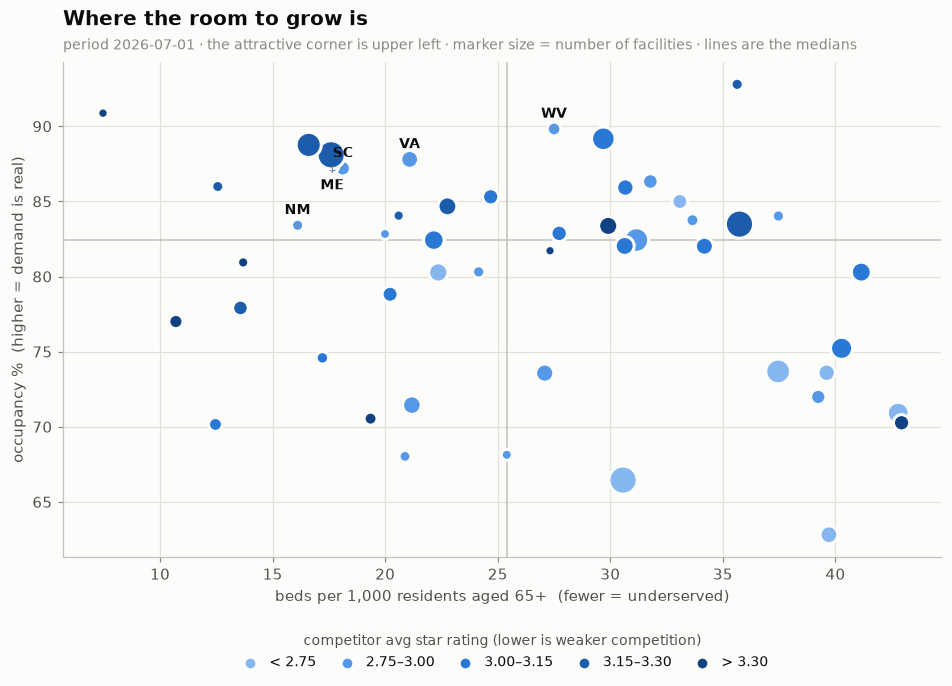

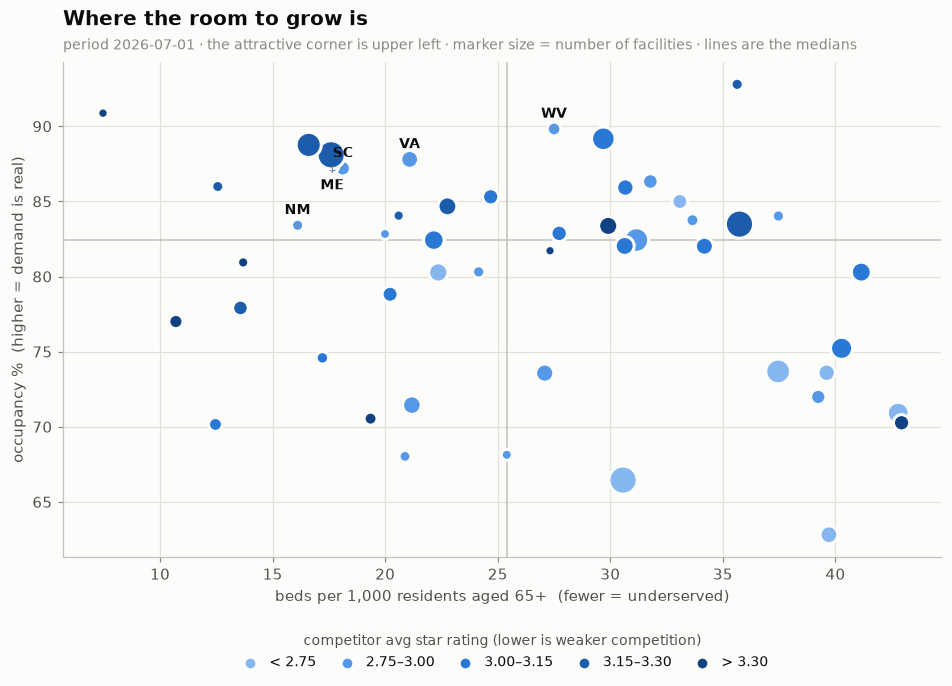

In [10]:
fig = charts.market_scatter(ranked, context, shortlist=5)
fig.savefig("bq1_market_scatter.png", dpi=150, bbox_inches="tight")
fig

## 8. คะแนนรวมมาจากอะไร

กราฟนี้แกะคะแนนรวมกลับเป็นสามส่วน เพื่อไม่ให้ตัวเลขเดียวซ่อนเหตุผลของตัวเอง
ถ้ารัฐหนึ่งขึ้นมาเพราะ "คู่แข่งอ่อน" เพียงอย่างเดียว ควรเห็นได้จากกราฟ

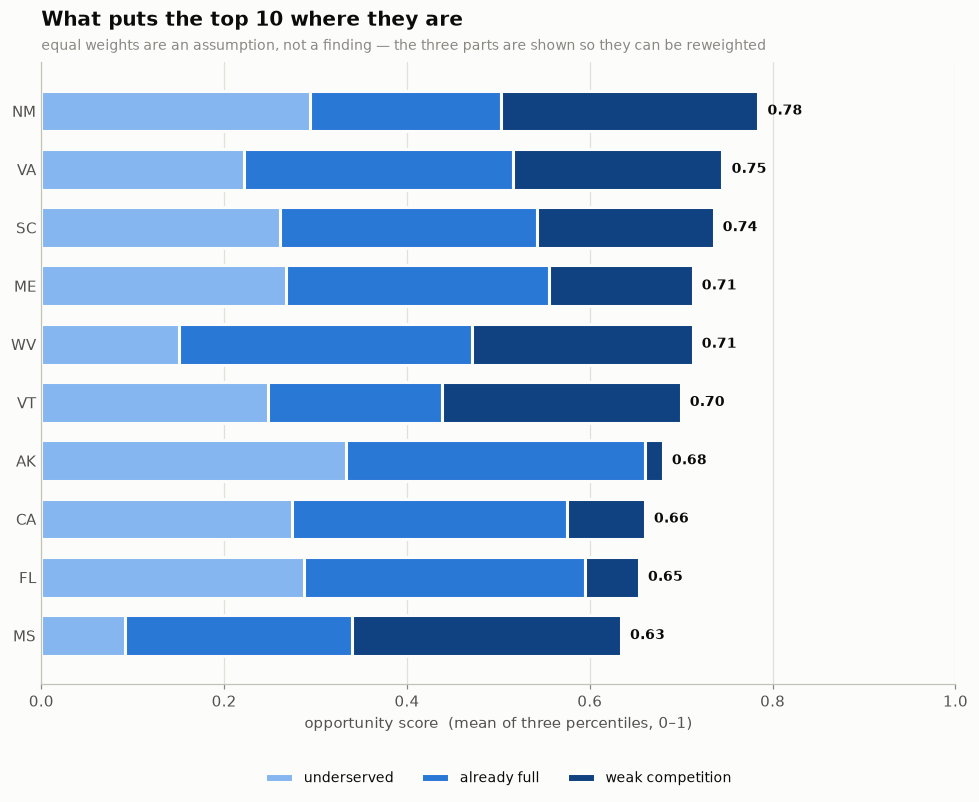

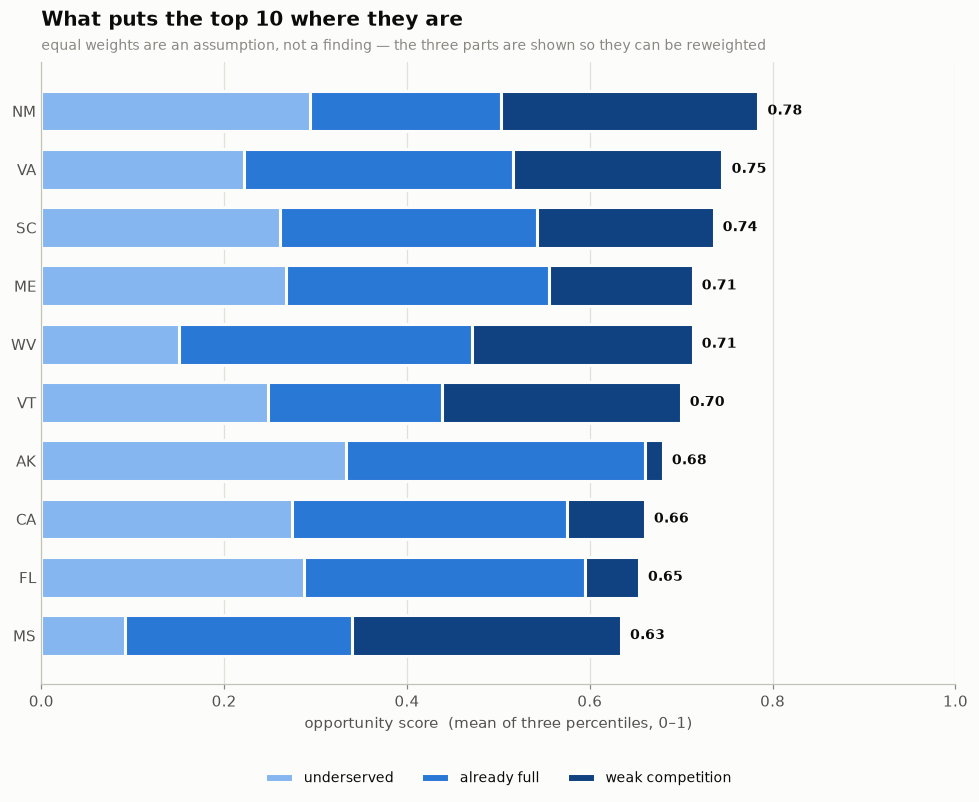

In [11]:
fig = charts.score_components_bar(ranked, top_n=10)
fig.savefig("bq1_score_components.png", dpi=150, bbox_inches="tight")
fig

## 9. คำตอบของ BQ1

_(เซลล์นี้สร้างข้อความจากตัวเลขจริง ไม่ได้พิมพ์มือ — รันใหม่เมื่อข้อมูลเปลี่ยนแล้วข้อความจะตามไปด้วย)_

In [12]:
top = ranked.dropna(subset=["opportunity_score"]).head(5)
bottom = ranked.dropna(subset=["opportunity_score"]).tail(3)

print(f"งวด {context['period']} · ประชากรปี {context['population_year']} · "
      f"จัดอันดับ {context['states_ranked']} รัฐ\n")
print("ห้ารัฐที่น่าลงทุนที่สุด\n")
for i, row in enumerate(top.itertuples(), 1):
    print(f"{i}. {row.state_name} ({row.state_code}) — คะแนน {row.opportunity_score:.2f}")
    print(f"     เตียงต่อผู้สูงอายุพันคน {row.beds_per_1k_65plus:5.1f} "
          f"(ประเทศ {context['national_beds_per_1k']:.1f})")
    print(f"     อัตราการเข้าพัก        {row.occupancy:5.1%}")
    print(f"     คะแนนคู่แข่ง           {row.avg_overall_rating:5.2f} / 5 "
          f"จาก {row.facilities} แห่ง")
    print()

print("ตลาดที่ควรเลี่ยง (อิ่มตัว คู่แข่งแข็ง):")
for row in bottom.itertuples():
    print(f"  {row.state_name} ({row.state_code}) — เตียง {row.beds_per_1k_65plus:.1f}/พันคน, "
          f"เข้าพัก {row.occupancy:.1%}, คู่แข่ง {row.avg_overall_rating:.2f}")

งวด 2026-07-01 · ประชากรปี 2024 · จัดอันดับ 51 รัฐ

ห้ารัฐที่น่าลงทุนที่สุด

1. New Mexico (NM) — คะแนน 0.78
     เตียงต่อผู้สูงอายุพันคน  16.1 (ประเทศ 25.6)
     อัตราการเข้าพัก        83.4%
     คะแนนคู่แข่ง            2.85 / 5 จาก 68 แห่ง

2. Virginia (VA) — คะแนน 0.75
     เตียงต่อผู้สูงอายุพันคน  21.1 (ประเทศ 25.6)
     อัตราการเข้าพัก        87.8%
     คะแนนคู่แข่ง            2.96 / 5 จาก 288 แห่ง

3. South Carolina (SC) — คะแนน 0.74
     เตียงต่อผู้สูงอายุพันคน  18.1 (ประเทศ 25.6)
     อัตราการเข้าพัก        87.2%
     คะแนนคู่แข่ง            3.00 / 5 จาก 186 แห่ง

4. Maine (ME) — คะแนน 0.71
     เตียงต่อผู้สูงอายุพันคน  17.7 (ประเทศ 25.6)
     อัตราการเข้าพัก        87.3%
     คะแนนคู่แข่ง            3.08 / 5 จาก 78 แห่ง

5. West Virginia (WV) — คะแนน 0.71
     เตียงต่อผู้สูงอายุพันคน  27.5 (ประเทศ 25.6)
     อัตราการเข้าพัก        89.8%
     คะแนนคู่แข่ง            2.94 / 5 จาก 121 แห่ง

ตลาดที่ควรเลี่ยง (อิ่มตัว คู่แข่งแข็ง):
  Iowa (IA) — เตียง 41.1/พันคน, เข้าพัก 80.3%, คู่

### ข้อจำกัดที่ต้องเขียนกำกับคำตอบนี้

1. **ประชากรเป็นปี 2024 แต่ข้อมูลสถานพยาบาลเป็นปี 2026** — ไฟล์ประมาณการประชากรของ
   Census มีถึงปี 2024 ประชากรสูงอายุโตประมาณ 3% ต่อปี ดังนั้นเตียงต่อพันคนที่คำนวณได้
   **สูงกว่าความจริงเล็กน้อยทุกรัฐ** แต่เป็นการเลื่อนไปทางเดียวกันทั้งหมด
   จึงไม่กระทบ*อันดับ* ซึ่งเป็นสิ่งที่ BQ1 ถาม
2. **ประชากรเป็นข้อมูลระดับรัฐ** จึงตอบได้แค่ระดับรัฐ ตอบระดับเมืองหรือ ZIP ไม่ได้
3. **ไม่ได้แยกประเภทเตียง** เตียง skilled nursing กับ long-term care ถูกนับรวมกัน
4. **คะแนนดาวเป็นคุณภาพที่ CMS วัด** ไม่ใช่ความสามารถในการทำกำไร
   รัฐที่คู่แข่งคะแนนต่ำอาจเป็นเพราะรัฐนั้นจ่าย Medicaid ต่ำจนไม่มีใครทำกำไรได้
   — ต้องดู BQ2 กับ BQ3 ประกอบ
5. **น้ำหนักเท่ากันทั้งสามตัวเป็นข้อสมมติ** ปรับ `pct_*` แล้วอันดับเปลี่ยนได้

## 10. ขั้นถัดไป

- ตัวเลขทั้งหมดในนี้มาจาก `queries.py` แอป Streamlit จะ `import queries` ตัวเดียวกัน
  แล้วเพิ่มตัวกรอง (งวด, รัฐ, สวิตช์ `is_suspect`) เป็น widget — ไม่ต้องเขียน query ใหม่
- ถ้าได้ Census API key แล้ว ตั้ง `CENSUS_API_KEY` แล้วรัน
  `python 02_ETL/population.py` ใหม่ ตัวเลขจะมาจาก ACS แทนไฟล์ประมาณการ
  และ `source` ในตารางจะบันทึกไว้เองว่ามาจากไหน
- BQ5 (แนวโน้ม 2562–2569) ต้องโหลด snapshot รายไตรมาสให้ครบก่อน ตอนนี้มี 4 งวด